In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import plotly.graph_objects as go

In [ ]:
f = "../data/001_raw/ERA5_Oaxaca_2023.nc"
oax = xr.open_dataset(f)

f = "../data/001_raw/ERA5_Morelos_2023.nc"
mor = xr.open_dataset(f)

<xarray.Dataset> Size: 96MB
Dimensions:    (time: 8760, latitude: 12, longitude: 19)
Coordinates:
  * time       (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
  * latitude   (latitude) float32 48B 18.5 18.25 18.0 17.75 ... 16.25 16.0 15.75
  * longitude  (longitude) float32 76B -98.5 -98.25 -98.0 ... -94.5 -94.25 -94.0
Data variables:
    u100       (time, latitude, longitude) float64 16MB ...
    v100       (time, latitude, longitude) float64 16MB ...
    u10        (time, latitude, longitude) float64 16MB ...
    v10        (time, latitude, longitude) float64 16MB ...
    t2m        (time, latitude, longitude) float64 16MB ...
    ssrd       (time, latitude, longitude) float64 16MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-03-28 09:15:45 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [3]:
def temperatura_celsius(estado, variable = "t2m"):
    """Función que convierte la temperatura de Kelvin a grados Celsius.

    Args:
        estado (xarray.Dataset): Dataset que contien las variables climáticas del estado.
        variable (str, optional): Nombre de la variable en el dataset. Defaults to "t2m".

    Returns:
        xarray.DataArray: Variable seleccionada expresada en grados Celsius.
    """
    
    return estado[variable] - 273.15

oax["t2m_celsius"] = temperatura_celsius(oax, "t2m")
mor["t2m_celsius"] = temperatura_celsius(mor, "t2m")


In [ ]:
def radiacion_w_m2(estado, variable = "ssrd"):
    """Convierte la radiación solar acumulada por hora de J/m2 a W/m2."""
   
    return estado[variable] / 3600.0
   

oax["ssrd_watts"] = radiacion_w_m2(oax, "ssrd")
mor["ssrd_watts"] = radiacion_w_m2(mor, "ssrd")


In [5]:
def aplicar_hora_local_mx(estado, nombre_estado, columna_tiempo='time'):
    """Convierte la columna de tiempo sin zona horaria a la hora local de un estado en México.

    Args:
        estado (pd.DataFrame): DataFrame del estado que contiene los datos a procesar.
        nombre_estado (str): Nombre del estado de México.
        columna_tiempo (str, optional): Nombre de la columna de fecha y hora. Defaults to 'time'.

    Returns:
        pd.DataFrame: El DataFrame modificado con las horas ajustadas al estado.
    """
    zonas = {
        'oaxaca': 'America/Mexico_City',
        'quintana_roo': 'America/Cancun',
        'baja_california': 'America/Tijuana',
        'baja_california_sur': 'America/Mazatlan',
        'sonora': 'America/Hermosillo',
        'sinaloa': 'America/Mazatlan',
        'chihuahua': 'America/Ciudad_Juarez'
    }
    
    estado_limpio = nombre_estado.lower().strip().replace(" ", "_")
    zona_correcta = zonas.get(estado_limpio, 'America/Mexico_City')
    
    estado[columna_tiempo] = pd.to_datetime(estado[columna_tiempo])
    
    if estado[columna_tiempo].dt.tz is None:
        estado[columna_tiempo] = estado[columna_tiempo].dt.tz_localize('UTC')
        
    estado[columna_tiempo] = estado[columna_tiempo].dt.tz_convert(zona_correcta).dt.tz_localize(None)
    return estado


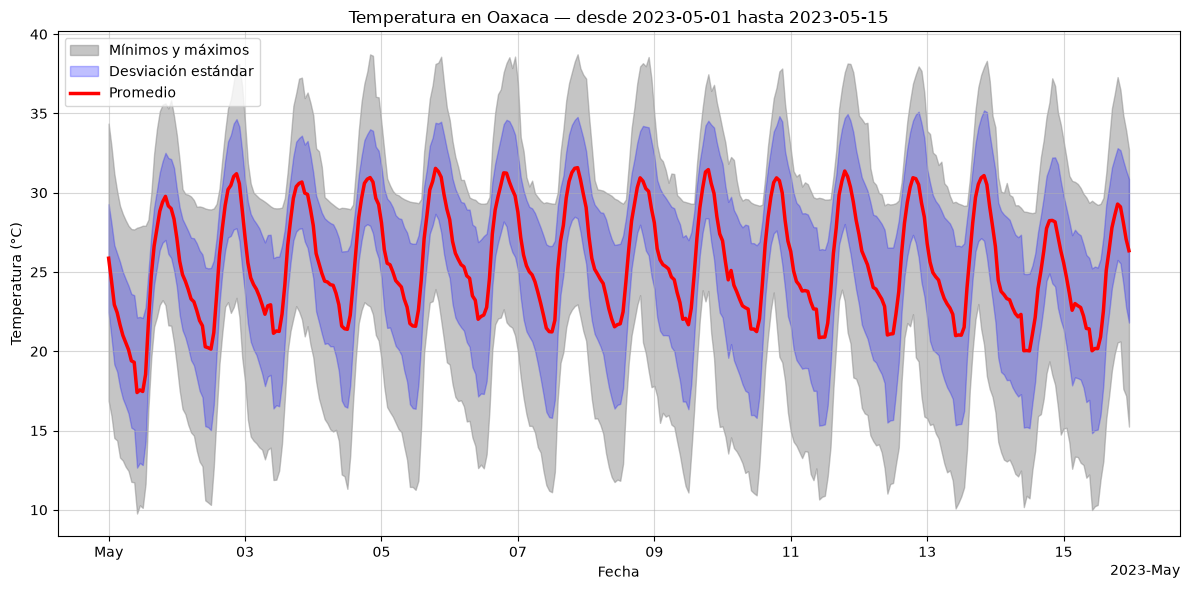

In [ ]:
def graficar_temperatura_desviacion(estado, nombre_estado, variable="t2m_celsius", fecha_inicio=None, fecha_fin=None):
    """Función para graficar una serie temporal con el promedio espacial, desviación estándar y mínimos-máximos.

    Permite recortar la serie por un rango de fechas. Si no se especifican, grafica el año completo.

    Args:
        estado (xarray.Dataset): Conjunto de datos climatológicos con dimensiones de tiempo, latitud y longitud.
        nombre_estado (str): Nombre de la entidad federativa para personalizar el título del gráfico.
        variable (str, optional): Nombre de la variable a procesar. Defaults to "t2m_celsius".
        fecha_inicio (str, optional): Fecha inicial en formato 'YYYY-MM-DD'. Defaults to None.
        fecha_fin (str, optional): Fecha final en formato 'YYYY-MM-DD'. Defaults to None.
    """
   
    estado_filtrado = estado


    if fecha_inicio and fecha_fin:
        estado_filtrado = estado.sel(time=slice(fecha_inicio, fecha_fin))
        titulo_fecha = f"desde {fecha_inicio} hasta {fecha_fin}"
    elif fecha_inicio:
        estado_filtrado = estado.sel(time=slice(fecha_inicio, None))
        titulo_fecha = f"desde {fecha_inicio}"
    else:
        titulo_fecha = "Año Completo (2023)"

    promedio = estado_filtrado[variable].mean(dim=["latitude", "longitude"])
    std = estado_filtrado[variable].std(dim=["latitude", "longitude"])
    v_max = estado_filtrado[variable].max(dim=["latitude", "longitude"])
    v_min = estado_filtrado[variable].min(dim=["latitude", "longitude"])
    
    _, ax = plt.subplots(figsize=(12, 6))

    ax.fill_between(promedio.time, 
                    v_min, 
                    v_max, 
                    color="gray", alpha=0.45, label="Mínimos y máximos"
                    )
    
    ax.fill_between(promedio.time, 
                    promedio - std, 
                    promedio + std, 
                    color="blue", alpha=0.25, label="Desviación estándar"
                    )
    

    promedio.plot(color="red", linewidth=2.5, label="Promedio", ax=ax)
    

    ax.set_title(f"Temperatura en {nombre_estado} — {titulo_fecha}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Temperatura (°C)" if "celsius" in variable else "Temperatura")
    ax.grid(True, alpha=0.5)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
graficar_temperatura_desviacion(oax, "Oaxaca", "t2m_celsius", "2023-05-01", "2023-05-15")



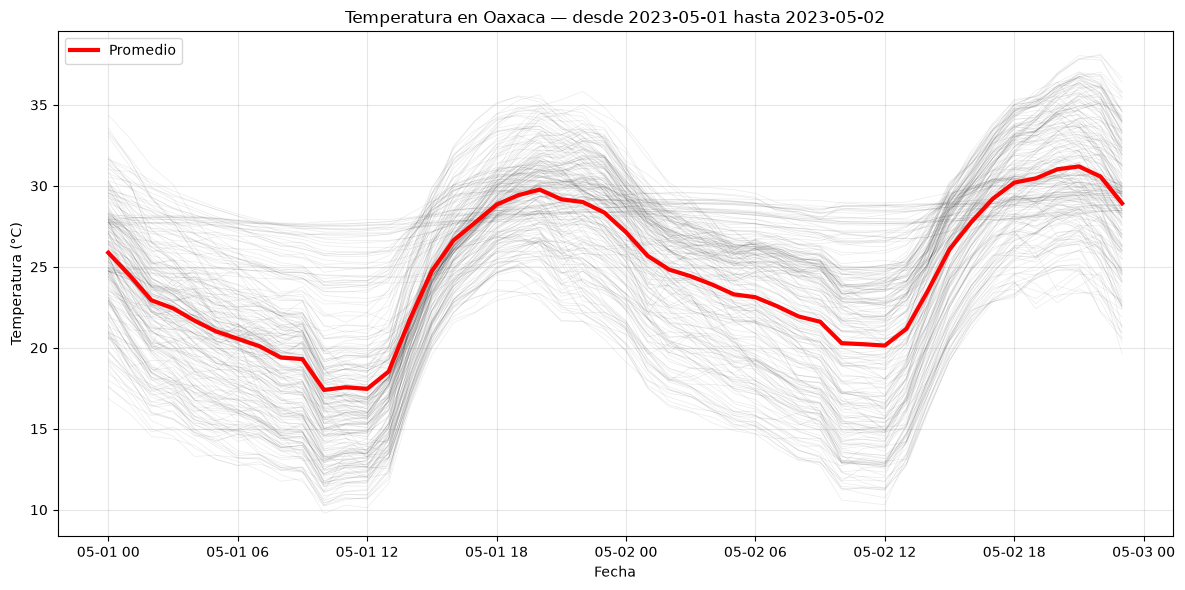

In [13]:
import matplotlib.pyplot as plt

def graficar_temperatura_lineas(estado, nombre_estado, variable="t2m_celsius", fecha_inicio=None, fecha_fin=None):
    """Crea un gráfico de espagueti con líneas semitransparentes para cada punto del mapa junto con el promedio regional.

    Args:
        estado (xarray.Dataset): Dataset con los datos climáticos organizados por tiempo y espacio.
        nombre_estado (str): Nombre de la entidad federativa para personalizar el título del gráfico.
        variable (str, optional): Nombre de la variable que se desea graficar. Defaults to "t2m_celsius".
        fecha_inicio (str, optional): Fecha inicial en formato 'YYYY-MM-DD'. Defaults to None.
        fecha_fin (str, optional): Fecha final en formato 'YYYY-MM-DD'. Defaults to None.
    """
    estado_filtrado = estado

    if fecha_inicio and fecha_fin:
        estado_filtrado = estado.sel(time=slice(fecha_inicio, fecha_fin))
        titulo_fecha = f"desde {fecha_inicio} hasta {fecha_fin}"
    elif fecha_inicio:
        estado_filtrado = estado.sel(time=slice(fecha_inicio, None))
        titulo_fecha = f"desde {fecha_inicio}"
    else:
        titulo_fecha = "Año Completo (2023)"
   
    promedio = estado_filtrado[variable].mean(dim=["latitude", "longitude"])
    
    _, ax = plt.subplots(figsize=(12, 6))
    
    temperaturas = estado_filtrado[variable].stack(punto=["latitude", "longitude"])
    
    ax.plot(temperaturas.time, temperaturas.values, color="k", alpha=0.08, linewidth=0.5)
    ax.plot(promedio.time, promedio.values, color="red", linewidth=3, label="Promedio")
    
    ax.set_title(f"Temperatura en {nombre_estado} — {titulo_fecha}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Temperatura (°C)" if "celsius" in variable else "Temperatura")
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

graficar_temperatura_lineas(oax, "Oaxaca", "t2m_celsius", "2023-05-01", "2023-05-02")


In [8]:
def filtrar_zona(estado, lat_norte, lat_sur, long_oeste, long_este):
    """Aplica un recorte por coordenadas para aislar un municipio o región en el mapa, mediante una caja de delimitación geográfica.

    Args:
        estado (xarray.Dataset): Dataset con la información meteorológica completa de la entidad.
        lat_norte (float): Punto decimal que define la frontera norte del área.
        lat_sur (float): Punto decimal que define la frontera sur del área.
        long_oeste (float): Límite oeste de la caja de selección (negativo).
        long_este (float): Límite este de la caja de selección (negativo).

    Returns:
        xarray.Dataset: Fragmento de datos correspondiente únicamente al cuadro delimitador.
    """

    area = estado.sel(
        latitude = slice (lat_norte,lat_sur),
        longitude = slice(long_oeste, long_este)
    )
    return area
    
huajuapan = filtrar_zona(oax,18.05,17.71,-97.92,-97.70)
huajuapan

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 8760, latitude: 2, longitude: 1)
Coordinates:
  * time         (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
  * latitude     (latitude) float32 8B 18.0 17.75
  * longitude    (longitude) float32 4B -97.75
Data variables:
    u100         (time, latitude, longitude) float64 140kB ...
    v100         (time, latitude, longitude) float64 140kB ...
    u10          (time, latitude, longitude) float64 140kB ...
    v10          (time, latitude, longitude) float64 140kB ...
    t2m          (time, latitude, longitude) float64 140kB 292.8 291.3 ... 295.2
    ssrd         (time, latitude, longitude) float64 140kB 2.877e+05 ... 1.14...
    t2m_celsius  (time, latitude, longitude) float64 140kB 19.63 18.11 ... 22.02
    ssrd_watts   (time, latitude, longitude) float64 140kB 79.92 83.36 ... 316.9
Attributes:
    Conventions:  CF-1.6
    history:      2024-03-28 09:15:45 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [9]:
def grafica_mapa_calor_universal(estado, nombre_estado, variable="t2m_celsius", fecha_inicio=None, fecha_fin=None):
    """Genera un mapa de calor personalizable para las variables "t2m_celsius" y "ssrd_watts".
    
    Permite filtrar por rangos de fechas o graficar de forma automática todo el año si no se especifican fechas.

    Args:
        estado (xarray.Dataset): Conjunto de datos climáticos del lugar a gráficar.
        nombre_estado (str): Nombre de la entidad federativa para el título.
        variable (str, optional): Variable a graficar ("t2m_celsius" o "ssrd_watts"). Defaults to "t2m_celsius".
        fecha_inicio (str, optional): Fecha inicial en formato 'YYYY-MM-DD'. Defaults to None.
        fecha_fin (str, optional): Fecha final en formato 'YYYY-MM-DD'. Defaults to None.
    """
    if "ssrd_watts" in variable:
        titulo_var = "Radiación Solar"
        unidad = "W/m²"
        escala_colores = "Plasma"
        hover_texto = f"Radiación: %{{z:.1f}} {unidad}"
    else:
        titulo_var = "Temperatura"
        unidad = "°C"
        escala_colores = [
            [0.0, "rgb(69, 117, 180)"],  
            [0.5, "rgb(254, 224, 144)"],  
            [1.0, "rgb(215, 48, 39)"]
        ]
        hover_texto = f"Temperatura: %{{z:.1f}} {unidad}"

    promedio = estado[variable].mean(dim=["latitude", "longitude"])
    estado = promedio.to_dataframe(name="valor").reset_index()
    
    estado = aplicar_hora_local_mx(estado, nombre_estado, columna_tiempo="time")
    
    estado["Fecha"] = estado["time"].dt.strftime('%d-%b') 
    estado["Hora"] = estado["time"].dt.hour
    
    if fecha_inicio and fecha_fin:
        limite_inicio = pd.to_datetime(fecha_inicio).date()
        limite_fin = pd.to_datetime(fecha_fin).date()
        estado = estado[(estado['time'].dt.date >= limite_inicio) & (estado['time'].dt.date <= limite_fin)].copy()
        titulo_fecha = f"desde {fecha_inicio} hasta {fecha_fin}"
    elif fecha_inicio:
        limite_inicio = pd.to_datetime(fecha_inicio).date()
        estado = estado[estado['time'].dt.date >= limite_inicio].copy()
        titulo_fecha = f"desde {fecha_inicio}"
    else:
        titulo_fecha = "Año Completo (2023)"

    columna_hora = estado.pivot_table(
        index="Hora", 
        columns="Fecha", 
        values="valor", 
        aggfunc="mean"
    )
    
    columnas_ordenadas = sorted(columna_hora.columns, key=lambda x: pd.to_datetime(x + '-2023', format='%d-%b-%Y'))
    columna_hora = columna_hora[columnas_ordenadas]

    fig = go.Figure(
        go.Heatmap(
            x=columna_hora.columns,   
            y=columna_hora.index,     
            z=columna_hora.values,    
            colorscale=escala_colores,
            xgap=1 if len(columna_hora.columns) > 31 else 2, 
            ygap=2,   
            colorbar=dict(title=f"{titulo_var} ({unidad})"),
            hovertemplate=f"<b>Fecha: %{{x}}</b><br>Hora: %{{y}}:00<br>{hover_texto}<extra></extra>",
        )
    )
    
    fig.update_layout(
        title=f"Mapa de Calor de {titulo_var} en {nombre_estado} — {titulo_fecha}",
        xaxis_title="Día del Año",
        yaxis_title="Hora del Día",
        xaxis=dict(
            tickmode="auto",
            nticks=20 
        ),
        yaxis=dict(
            tickmode="linear",
            tick0=0,
            dtick=2 
        ),
        height=550, 
        template="plotly_white"
    )

    fig.show()
    return fig

fig_mayo = grafica_mapa_calor_universal(
    huajuapan, 
    "Oaxaca", 
    "ssrd_watts","2023-01-01","2023-01-02"
)
